In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/uciml/breast-cancer-wisconsin-data/data.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/uciml/breast-cancer-wisconsin-data/data.csv')

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
df.drop(columns=["id"], inplace=True)

In [6]:
df.drop(columns=["Unnamed: 32"], inplace=True)

In [7]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
df["diagnosis"] = df["diagnosis"].map({
    "B": 0,
    "M": 1
})

In [9]:
df["diagnosis"].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

In [10]:
df["diagnosis"].dtype

dtype('int64')

In [11]:
df.isnull().sum().sort_values(ascending=False)

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["diagnosis"].value_counts(normalize=True) * 100

diagnosis
0    62.741652
1    37.258348
Name: proportion, dtype: float64

<Axes: xlabel='diagnosis'>

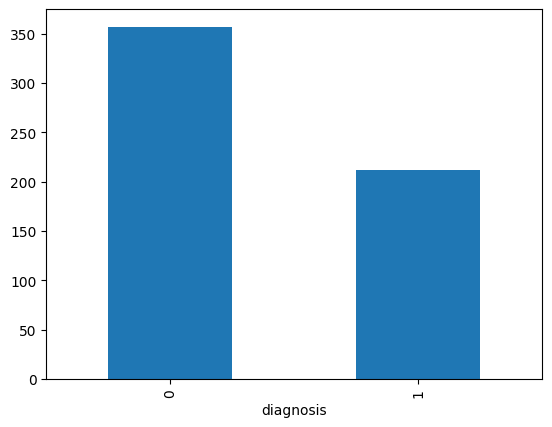

In [14]:
df["diagnosis"].value_counts().plot(kind="bar")

The target variable shows a moderate class imbalance, with approximately 62.7% benign cases and 37.3% malignant cases. The imbalance is not extreme, but evaluation should include metrics such as recall, precision, F1-score, and ROC-AUC in addition to accuracy.

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="diagnosis")
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts(normalize=True)*100)
print(y_test.value_counts(normalize=True)*100)

(455, 30)
(114, 30)
diagnosis
0    62.637363
1    37.362637
Name: proportion, dtype: float64
diagnosis
0    63.157895
1    36.842105
Name: proportion, dtype: float64


# **EDA**

In [17]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
radius_mean,455.0,14.166077,3.579081,6.981000,11.710000,13.340000,15.935000,28.11000
texture_mean,455.0,19.417692,4.290653,9.710000,16.335000,18.900000,21.830000,39.28000
perimeter_mean,455.0,92.215868,24.717118,43.790000,75.235000,86.180000,104.500000,188.50000
area_mean,455.0,659.578242,360.418686,143.500000,420.400000,546.400000,795.500000,2501.00000
smoothness_mean,455.0,0.095993,0.014310,0.062510,0.085130,0.095240,0.104900,0.16340
compactness_mean,455.0,0.103835,0.053910,0.019380,0.063735,0.092280,0.130350,0.34540
concavity_mean,455.0,0.089184,0.081698,0.000000,0.029520,0.059400,0.132200,0.42680
concave points_mean,455.0,0.049015,0.039686,0.000000,0.019685,0.033340,0.074075,0.20120
symmetry_mean,455.0,0.181497,0.027646,0.106000,0.162050,0.179900,0.195400,0.30400
fractal_dimension_mean,455.0,0.062715,0.006971,0.050240,0.057635,0.061300,0.066370,0.09744


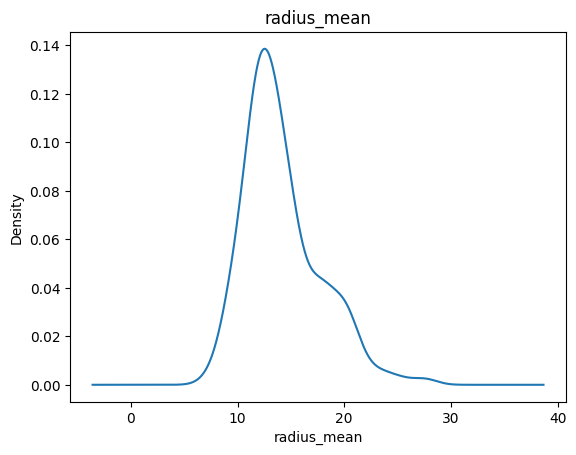

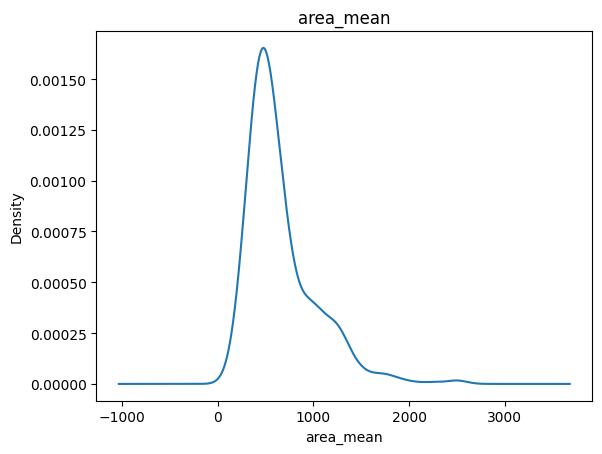

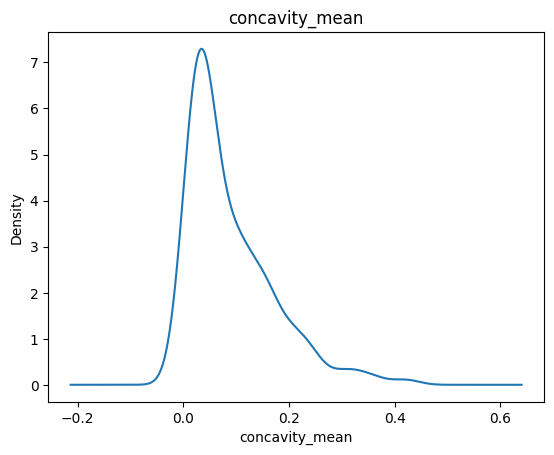

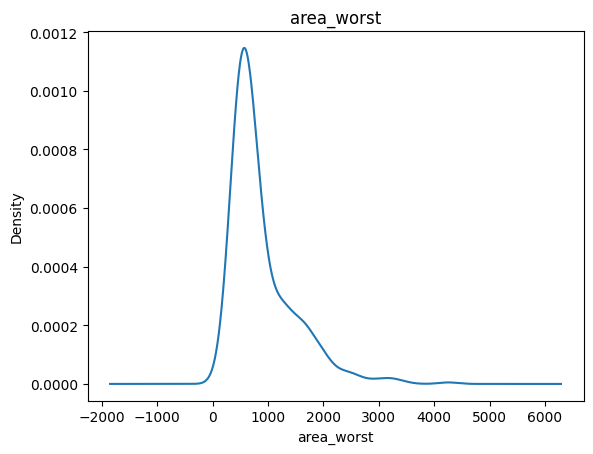

In [18]:
import matplotlib.pyplot as plt

features = [
    "radius_mean",
    "area_mean",
    "concavity_mean",
    "area_worst"
]

for col in features:
    X_train[col].plot(kind="kde")
    plt.title(col)
    plt.xlabel(col)
    plt.show()

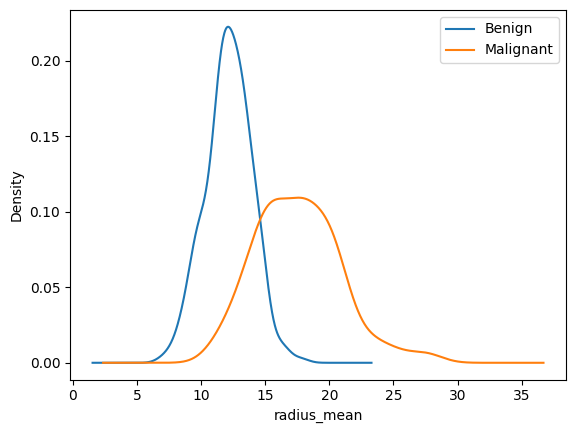

In [19]:
temp = X_train.copy()
temp["diagnosis"] = y_train

temp[temp["diagnosis"] == 0]["radius_mean"].plot(
    kind="kde",
    label="Benign"
)

temp[temp["diagnosis"] == 1]["radius_mean"].plot(
    kind="kde",
    label="Malignant"
)

plt.xlabel("radius_mean")
plt.legend()
plt.show()

The overlap region tells me where classification becomes uncertain. A decision stump searches around possible feature values and selects the threshold that gives the lowest weighted classification error. In this dataset, because benign tumors tend to have smaller radius and malignant tumors larger radius, the split will likely look like smaller radius → benign and larger radius → malignant.
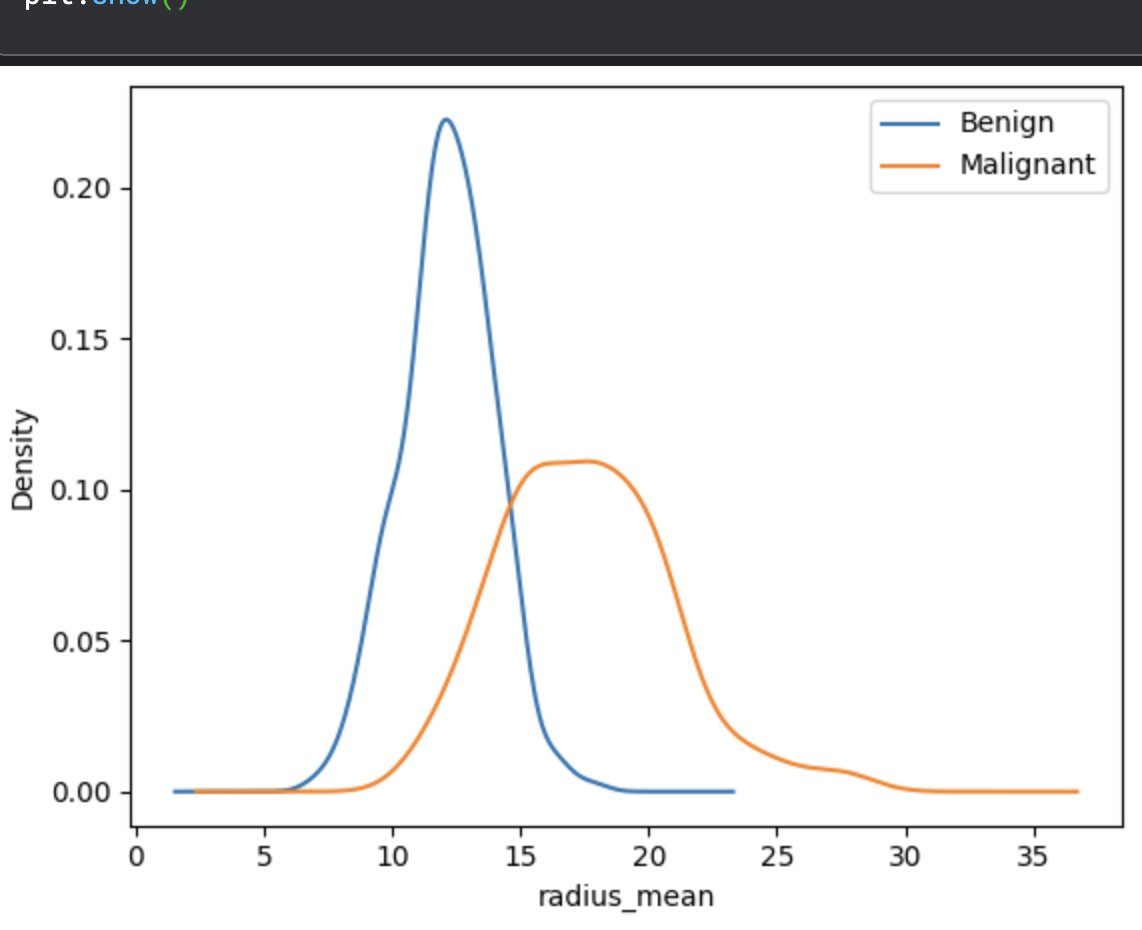

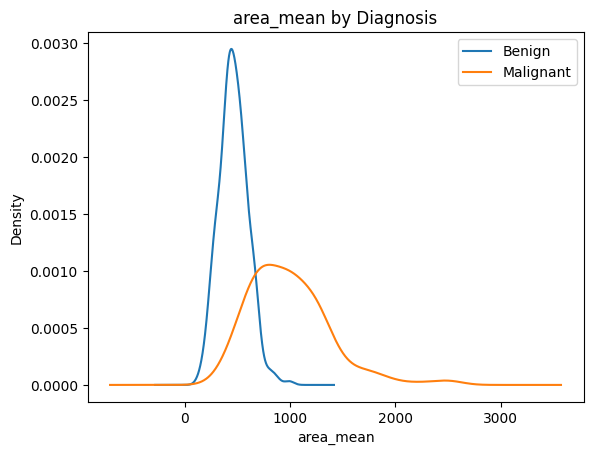

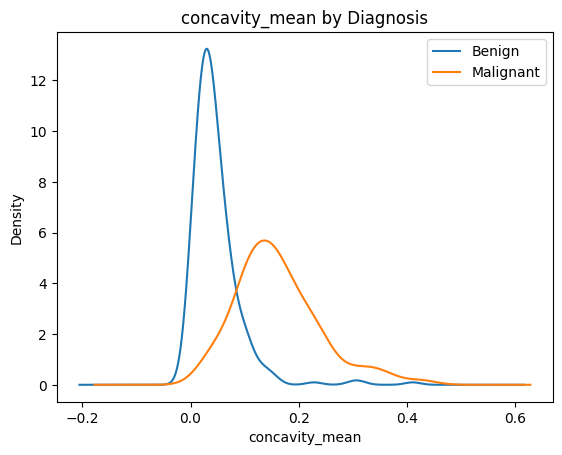

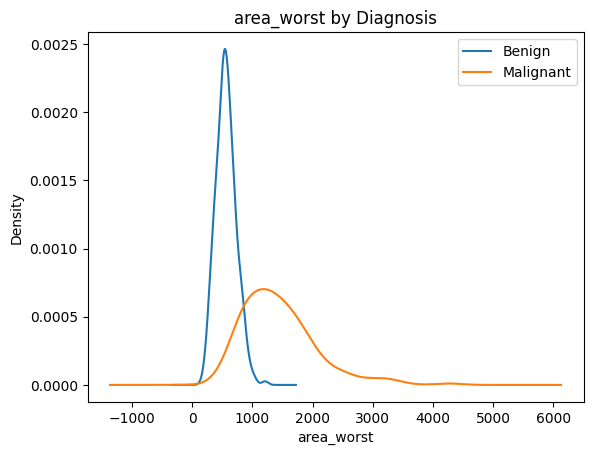

In [20]:
import matplotlib.pyplot as plt

temp = X_train.copy()
temp["diagnosis"] = y_train

features = [
    "area_mean",
    "concavity_mean",
    "area_worst"
]

for col in features:
    temp[temp["diagnosis"] == 0][col].plot(
        kind="kde",
        label="Benign"
    )

    temp[temp["diagnosis"] == 1][col].plot(
        kind="kde",
        label="Malignant"
    )

    plt.title(f"{col} by Diagnosis")
    plt.xlabel(col)
    plt.legend()
    plt.show()

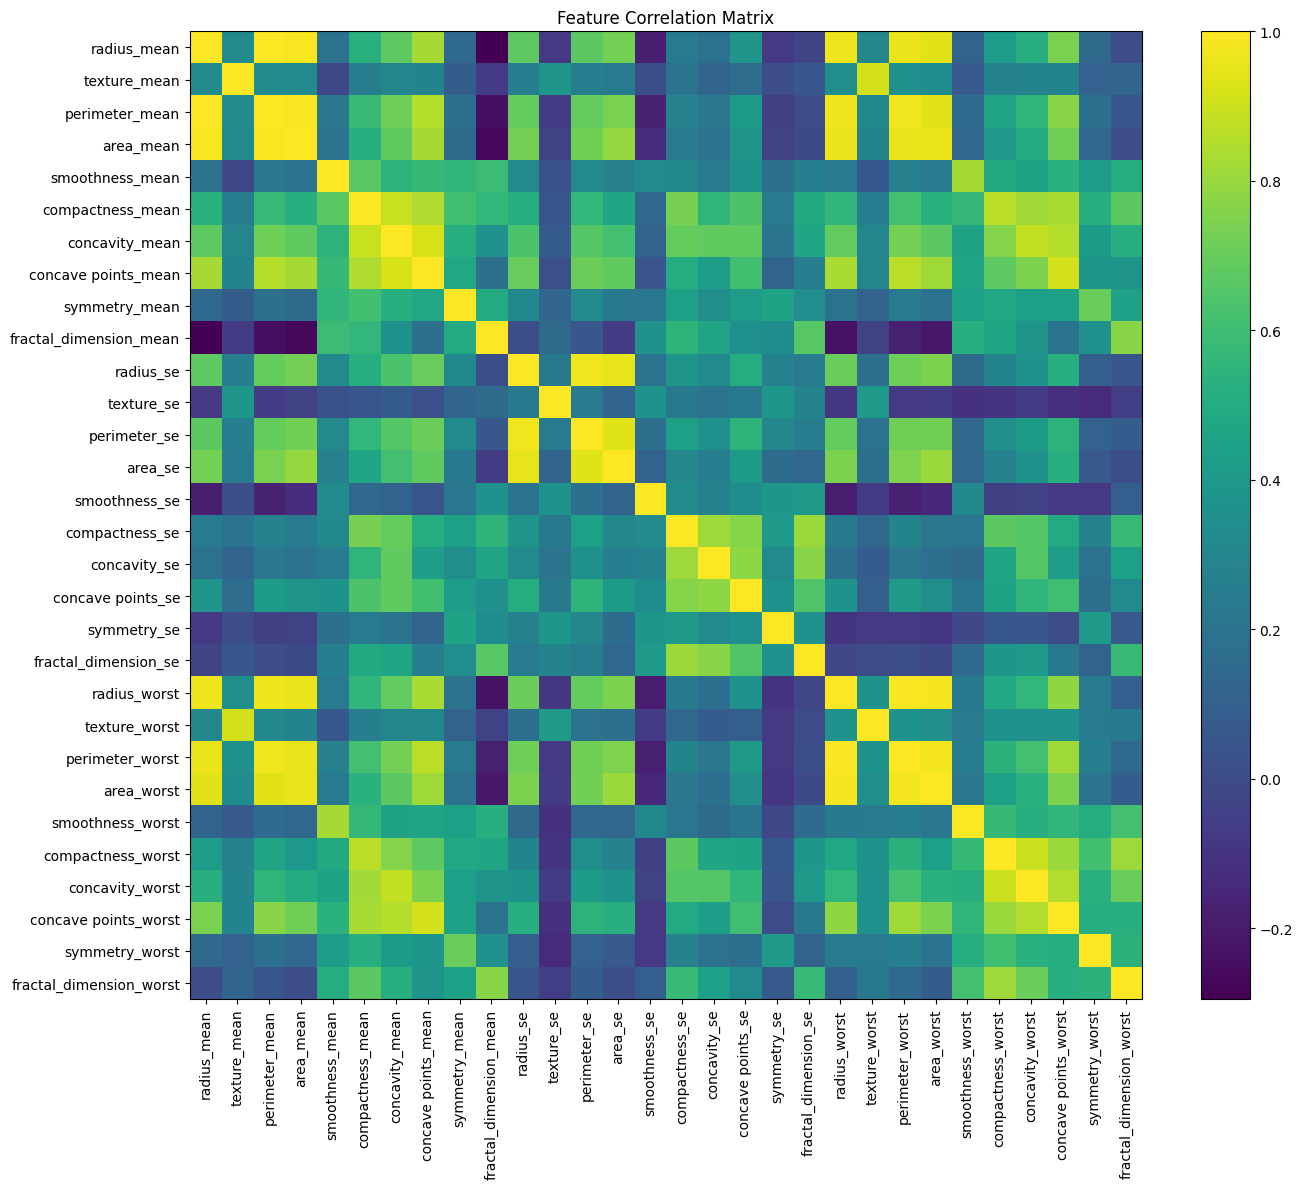

In [21]:
corr = X_train.corr()


plt.figure(figsize=(14, 12))
plt.imshow(corr, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [22]:
temp = X_train.copy()
temp["diagnosis"] = y_train

temp.corr()["diagnosis"].sort_values(ascending=False)

diagnosis                  1.000000
concave points_worst       0.786306
perimeter_worst            0.782881
radius_worst               0.777602
concave points_mean        0.775737
perimeter_mean             0.740027
area_worst                 0.731761
radius_mean                0.728160
area_mean                  0.703893
concavity_mean             0.683688
concavity_worst            0.643116
compactness_mean           0.606479
compactness_worst          0.587045
radius_se                  0.558572
perimeter_se               0.546759
area_se                    0.533848
texture_worst              0.466666
smoothness_worst           0.431637
symmetry_worst             0.426215
texture_mean               0.413595
concave points_se          0.402364
smoothness_mean            0.388584
symmetry_mean              0.341308
fractal_dimension_worst    0.326102
compactness_se             0.284951
concavity_se               0.227480
fractal_dimension_se       0.070343
symmetry_se                0

In [23]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

ada.fit(X_train, y_train)

y_pred = ada.predict(X_test)

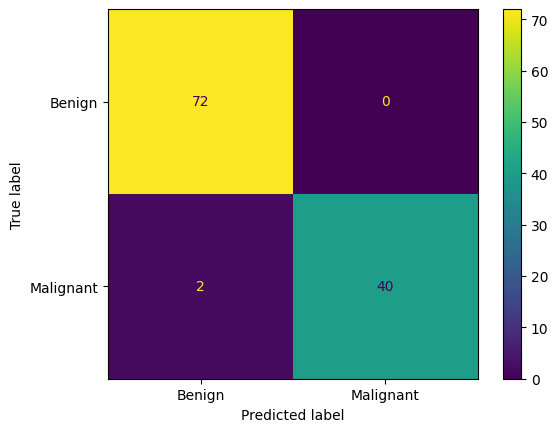

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot()
plt.show()

In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9824561403508771
Precision: 1.0
Recall   : 0.9523809523809523
F1 Score : 0.975609756097561


In [26]:
importance = pd.Series(
    ada.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(10))

concave points_worst    0.114789
perimeter_worst         0.103677
compactness_se          0.086224
texture_mean            0.085571
texture_worst           0.083780
area_se                 0.080973
concave points_mean     0.060447
compactness_mean        0.059730
smoothness_mean         0.056982
concavity_worst         0.049273
dtype: float64


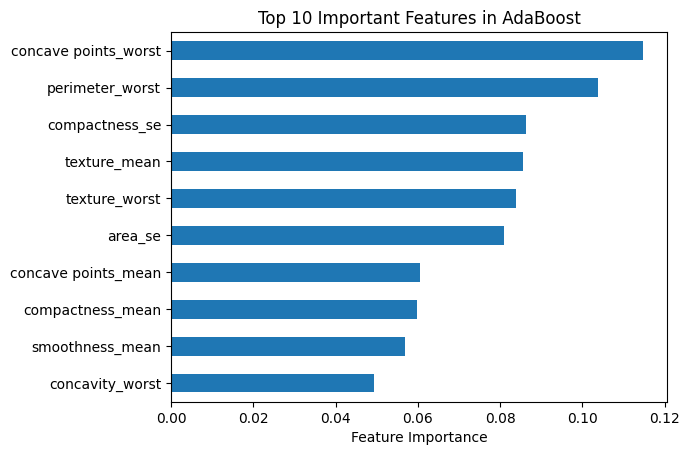

In [27]:
importance.head(10).sort_values().plot(kind="barh")

plt.xlabel("Feature Importance")
plt.title("Top 10 Important Features in AdaBoost")
plt.show()

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

base_tree = DecisionTreeClassifier(random_state=42)

ada = AdaBoostClassifier(
    estimator=base_tree,
    random_state=42
)

param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.1, 0.5, 1.0],
    "estimator__max_depth": [1, 2, 3]
}

grid = GridSearchCV(
    estimator=ada,
    param_grid=param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=42),
                                          random_state=42),
             n_jobs=-1,
             param_grid={'estimator__max_depth': [1, 2, 3],
                         'learning_rate': [0.1, 0.5, 1.0],
                         'n_estimators': [50, 100, 200]},
             scoring='recall')

In [29]:
print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV Recall:")
print(grid.best_score_)

Best Parameters:
{'estimator__max_depth': 2, 'learning_rate': 0.5, 'n_estimators': 50}

Best CV Recall:
0.9588235294117646


In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

base_tree = DecisionTreeClassifier(random_state=42)

ada = AdaBoostClassifier(
    estimator=base_tree,
    random_state=42
)

param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.1, 0.5, 1.0],
    "estimator__max_depth": [1, 2, 3]
}

grid = GridSearchCV(
    estimator=ada,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=42),
                                          random_state=42),
             n_jobs=-1,
             param_grid={'estimator__max_depth': [1, 2, 3],
                         'learning_rate': [0.1, 0.5, 1.0],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [31]:
print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV accuracy:")
print(grid.best_score_)

Best Parameters:
{'estimator__max_depth': 2, 'learning_rate': 0.5, 'n_estimators': 50}

Best CV accuracy:
0.9736263736263737


In [32]:
y_pred_best = grid.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))

Accuracy : 0.9736842105263158
Precision: 1.0
Recall   : 0.9285714285714286
F1 Score : 0.9629629629629629


In [34]:
print(grid.best_params_)
print(grid.best_score_)

{'estimator__max_depth': 2, 'learning_rate': 0.5, 'n_estimators': 50}
0.9736263736263737


In [35]:
from sklearn.model_selection import cross_val_score

baseline_cv_scores = cross_val_score(
    ada,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Fold recalls:", baseline_cv_scores)
print("Mean CV recall:", baseline_cv_scores.mean())

Fold recalls: [0.96703297 0.94505495 0.9010989  0.97802198 0.86813187]
Mean CV recall: 0.9318681318681318
